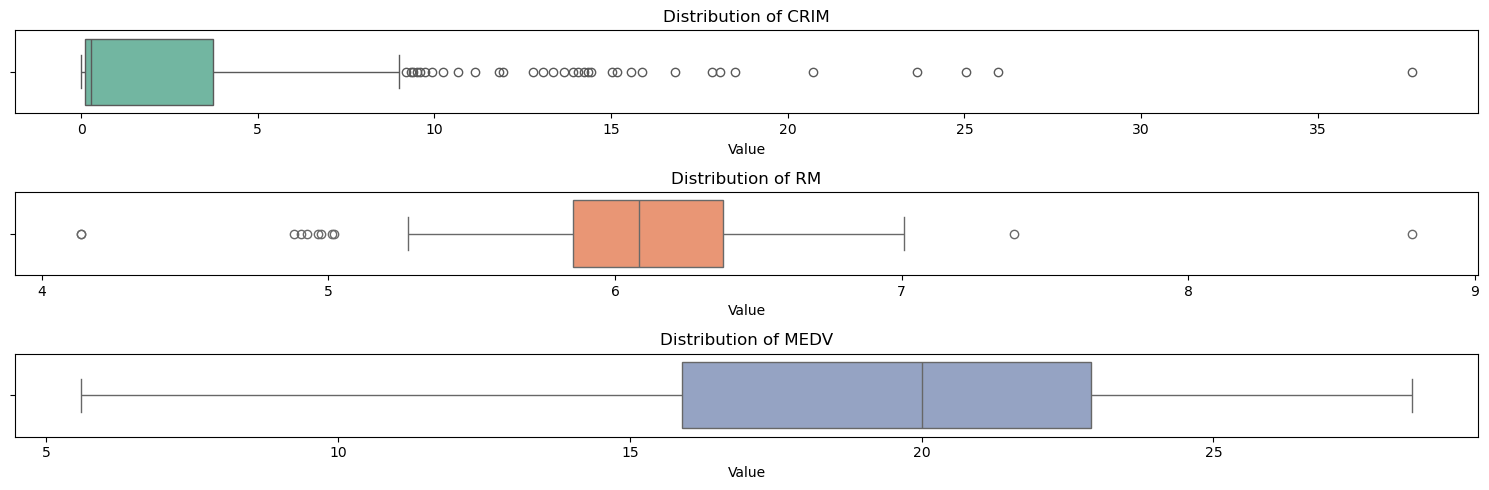

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("boston-housing.csv")
fig, axes = plt.subplots(nrows=3, ncols = 1, figsize=(15,5))

for i, col in enumerate(df.columns):
    sns.boxplot(x=df[col], ax = axes[i], color =sns.color_palette("Set2")[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('Value')

plt.tight_layout()
    

In [2]:
import statsmodels.api as sm

X = df[['CRIM','RM']] #inputs
y = df['MEDV'] #output
X = sm.add_constant(X) #for adding \beta_0

model = sm.OLS(y,X).fit()
print(model.summary())



                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.445
Method:                 Least Squares   F-statistic:                     107.8
Date:                Tue, 05 May 2026   Prob (F-statistic):           6.03e-35
Time:                        10:23:35   Log-Likelihood:                -712.99
No. Observations:                 267   AIC:                             1432.
Df Residuals:                     264   BIC:                             1443.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5088      2.822      0.889      0.3

In [16]:
import numpy as np
from numpy import linalg as la
beta = la.inv(np.transpose(X)@X)@np.transpose(X)@y
x = [1, 5, 3]
beta@x

np.float64(9.081700770860316)

In [11]:
df['CRIM_RM'] = df['CRIM']*df['RM']
X_int = sm.add_constant(df[['CRIM','RM','CRIM_RM']])
model_int = sm.OLS(y,X_int).fit()
print(model_int.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.485
Method:                 Least Squares   F-statistic:                     84.43
Date:                Tue, 05 May 2026   Prob (F-statistic):           2.74e-38
Time:                        09:26:18   Log-Likelihood:                -702.63
No. Observations:                 267   AIC:                             1413.
Df Residuals:                     263   BIC:                             1428.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.6236      3.497     -2.180      0.0